# Was the descriptor worth it?

Everything in this stage rests on a choice made before any of it: crops are represented by DINOv2
ViT-B/14 embeddings. Nothing so far tests that choice. If a cheap descriptor separated designs as
well, the stage would still stand but its cost and its dependence on a pretrained network would be
unjustified.

Four representations are compared on the same annotated pairs: the DINOv2 embedding, its
50-dimensional PCA projection, which is what the clustering actually consumes, a downsampled 32 by
32 bitmap, and a HOG descriptor. All four are compared by the area under the ROC curve of their
cosine similarity against the human labels, which is threshold free and therefore does not depend on
any operating point.

This notebook changes nothing. It runs after the selection and cannot revise it.

## 1. Setup

Each crop is preprocessed exactly as in notebook 1: grayscale, Otsu, padded to a square canvas,
resized. The pixel and HOG descriptors are computed from that same canvas, so the comparison is
between representations rather than between preprocessing pipelines.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from skimage.feature import hog
from skimage.filters import threshold_otsu
from sklearn.metrics import roc_auc_score

NOTEBOOK_DIR = Path.cwd().resolve()
assert NOTEBOOK_DIR.name == '2_clustering', \
    'Run this notebook from its own folder, 2_clustering/.'
PROJECT_DIR = NOTEBOOK_DIR.parent

RUN_TAG = '_rerun1'
RANDOM_SEED = 42
BOOTSTRAP_DRAWS = 2000
CANVAS = 224

FEATURE_RUN_ID = 'all_regions_v1_minside24_dinov2_vitb14_binarized_v1'
BENCHMARK_DIR = PROJECT_DIR / '2_clustering_outputs' / f'{FEATURE_RUN_ID}_clustering_benchmark_v1'
METHOD_DIR = BENCHMARK_DIR / 'method_comparison'
FEATURE_DIR = PROJECT_DIR / 'feature_extraction_outputs' / FEATURE_RUN_ID
OUTPUT_DIR = BENCHMARK_DIR / f'representation_v1{RUN_TAG}'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

manifest = pd.read_csv(METHOD_DIR / 'selected_clusters.csv')
features = np.load(FEATURE_DIR / 'dino_features_binarized.npy', mmap_mode='r')
pca_features = np.load(METHOD_DIR / 'pca_50d.npy')

pairs = pd.read_csv(BENCHMARK_DIR / 'pair_review' / 'pair_candidates.csv').merge(
    pd.read_csv(BENCHMARK_DIR / 'pair_review' / 'pair_review_labels.csv')[['pair_id', 'label']],
    on='pair_id')
pairs = pairs[pairs.label.isin(['same_fleuron', 'different'])].copy()
truth = pairs.label.eq('same_fleuron').to_numpy().astype(int)
print(f'{len(pairs)} identity pairs: {int(truth.sum())} same_fleuron, '
      f'{int((1 - truth).sum())} different')

150 identity pairs: 134 same_fleuron, 16 different


In [2]:
def preprocess(relative_path):
    """Grayscale, Otsu, pad to a square canvas, resize. The pipeline of notebook 1."""
    grey = np.asarray(Image.open(PROJECT_DIR / relative_path).convert('L'), dtype=np.uint8)
    binary = (np.full_like(grey, 255) if grey.min() == grey.max()
              else np.where(grey > threshold_otsu(grey), 255, 0).astype(np.uint8))
    height, width = binary.shape
    side = max(height, width)
    canvas = np.full((side, side), 255, dtype=np.uint8)
    top, left = (side - height) // 2, (side - width) // 2
    canvas[top:top + height, left:left + width] = binary
    return np.asarray(Image.fromarray(canvas).resize((CANVAS, CANVAS), Image.BICUBIC),
                      dtype=np.float32) / 255.0


needed = sorted(set(pairs.left_index) | set(pairs.right_index))
images = {index: preprocess(manifest.crop_path.iloc[index]) for index in needed}

representations = {
    'DINOv2 ViT-B/14 (768d)': {i: np.asarray(features[i]) for i in needed},
    'DINOv2 + PCA 50d': {i: pca_features[i] for i in needed},
    'HOG (9 orientations, 16px cells)': {
        i: hog(image, orientations=9, pixels_per_cell=(16, 16), cells_per_block=(2, 2),
               block_norm='L2-Hys', feature_vector=True).astype(np.float32)
        for i, image in images.items()},
    'raw pixels 32x32': {
        i: np.asarray(Image.fromarray((image * 255).astype(np.uint8)).resize((32, 32),
                      Image.BICUBIC), dtype=np.float32).ravel() / 255.0
        for i, image in images.items()},
}
print(f'{len(needed)} distinct crops preprocessed, {len(representations)} representations')

291 distinct crops preprocessed, 4 representations


## 2. How well each representation separates the labelled pairs

For every pair, the cosine similarity between its two crops is computed in each representation, and
scored against the human label by area under the ROC curve. AUC is used rather than precision at a
threshold because it is invariant to where an operating point would be placed, and because notebook
3 established that this annotation cannot support threshold-level comparisons: it holds sixteen
negative pairs.

Intervals come from resampling the pairs 2,000 times.

In [3]:
def cosine(vectors, left, right):
    a, b = vectors[left], vectors[right]
    scale = np.linalg.norm(a) * np.linalg.norm(b)
    return float(a @ b / scale) if scale else 0.0


generator = np.random.default_rng(RANDOM_SEED)
similarity, rows = {}, []
for name, vectors in representations.items():
    scores = np.array([cosine(vectors, left, right)
                       for left, right in zip(pairs.left_index, pairs.right_index)])
    similarity[name] = scores
    draws = []
    for _ in range(BOOTSTRAP_DRAWS):
        pick = generator.integers(0, len(truth), len(truth))
        if len(set(truth[pick])) == 2:
            draws.append(roc_auc_score(truth[pick], scores[pick]))
    low, high = np.percentile(draws, [2.5, 97.5])
    rows.append({'representation': name, 'dimensions': len(next(iter(vectors.values()))),
                 'auc': roc_auc_score(truth, scores),
                 'ci95_lower': float(low), 'ci95_upper': float(high)})

ablation = pd.DataFrame(rows).sort_values('auc', ascending=False)
ablation.to_csv(OUTPUT_DIR / 'representation_auc.csv', index=False)
display(ablation.set_index('representation').round(3))

,dimensions,auc,ci95_lower,ci95_upper
representation,,,,
DINOv2 ViT-B/14 (768d),768,0.878,0.816,0.929
DINOv2 + PCA 50d,50,0.872,0.790,0.941
raw pixels 32x32,1024,0.841,0.745,0.923
"HOG (9 orientations, 16px cells)",6084,0.816,0.744,0.882


## 3. Are the differences real?

Comparing the intervals above would be the wrong test, because all four representations are scored
on the *same* pairs and their errors are correlated. The difference is therefore resampled directly:
each draw takes one bootstrap sample of the pairs and records the gap in AUC between DINOv2 and each
alternative on that same sample. An interval that contains zero means the ordering above is not
distinguishable from sampling noise.

In [4]:
reference = 'DINOv2 ViT-B/14 (768d)'
others = [name for name in representations if name != reference]
generator = np.random.default_rng(RANDOM_SEED)
gaps = {name: [] for name in others}
for _ in range(BOOTSTRAP_DRAWS):
    pick = generator.integers(0, len(truth), len(truth))
    if len(set(truth[pick])) < 2:
        continue
    base = roc_auc_score(truth[pick], similarity[reference][pick])
    for name in others:
        gaps[name].append(base - roc_auc_score(truth[pick], similarity[name][pick]))

paired = pd.DataFrame([
    {'comparison': f'DINOv2 minus {name}',
     'mean_delta_auc': float(np.mean(gaps[name])),
     'ci95_lower': float(np.percentile(gaps[name], 2.5)),
     'ci95_upper': float(np.percentile(gaps[name], 97.5)),
     'excludes_zero': bool(np.percentile(gaps[name], 2.5) > 0
                           or np.percentile(gaps[name], 97.5) < 0)}
    for name in others])
paired.to_csv(OUTPUT_DIR / 'representation_paired_bootstrap.csv', index=False)
display(paired.set_index('comparison').round(3))

,mean_delta_auc,ci95_lower,ci95_upper,excludes_zero
comparison,,,,
DINOv2 minus DINOv2 + PCA 50d,0.006,-0.051,0.068,False
"DINOv2 minus HOG (9 orientations, 16px cells)",0.060,-0.016,0.137,False
DINOv2 minus raw pixels 32x32,0.036,-0.056,0.138,False


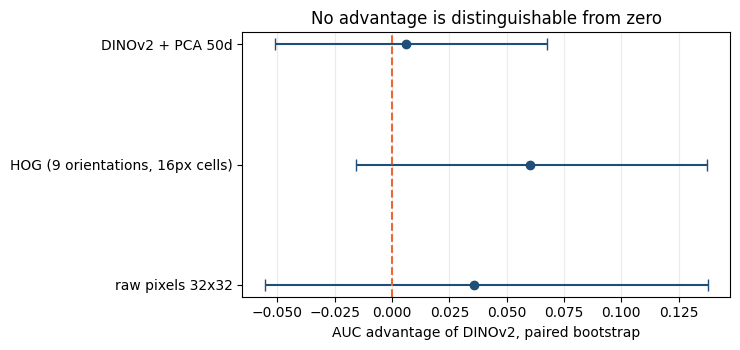

In [5]:
figure, axis = plt.subplots(figsize=(7.5, 3.6))
order = paired.iloc[::-1]
positions = np.arange(len(order))
axis.errorbar(order.mean_delta_auc, positions,
              xerr=[order.mean_delta_auc - order.ci95_lower,
                    order.ci95_upper - order.mean_delta_auc],
              fmt='o', color='#1f4e79', capsize=4)
axis.axvline(0, color='#eb6834', linestyle='--')
axis.set(yticks=positions,
         yticklabels=[name.replace('DINOv2 minus ', '') for name in order.comparison],
         xlabel='AUC advantage of DINOv2, paired bootstrap',
         title='No advantage is distinguishable from zero')
axis.grid(axis='x', alpha=0.25)
figure.tight_layout()
figure.savefig(OUTPUT_DIR / 'representation_delta_auc.png', dpi=180, bbox_inches='tight')
plt.show()

## 4. Conclusion

**DINOv2 ranks first and cannot be shown to be better.** It reaches the highest AUC of the four, but
every paired interval against an alternative contains zero. On this annotation, a **32 by 32
downsampled bitmap** is not measurably worse than a pretrained vision transformer at deciding
whether two fleuron crops show the same design.

That is a limitation of the evidence rather than a claim about representations in general. The
comparison rests on the same sixteen negative pairs that notebook 3 showed could not separate
clustering methods.

**The bias in the sample runs towards DINOv2, which is why the null result holds.** The pairs were
stratified by DINO similarity and the high bands partly use DINO neighbours, so the benchmark is
built in the favour of the representation being tested. A test tilted towards one competitor on
which that competitor still cannot win makes the negative result conservative: removing the tilt
could only narrow the gap. The tilt would undermine a claim that DINOv2 is better, which is not
made here.

**PCA to 50 dimensions shows little loss.** The projection the clustering actually consumes differs
by 0.006 AUC from the full embedding, with an interval spanning zero. The same reasoning applies,
since the sample favours the full embedding over its own projection, so 0.006 is an upper bound on
the loss rather than an estimate of it. A crop-disjoint sample selected independently of every
representation would be needed to put a number on either comparison.

**What follows for the stage.** Nothing is revised. The descriptor is retained on the grounds that
it ranks first, is already computed, and supports the retrieval stage that follows, and the chapter
states plainly that a cheaper descriptor was not shown to be worse.